# Signed log-growth model

Build a word-week panel from the raw comment JSON files, then run rolling 14+1 train/test folds.

Target:

`y = log(smoothed_next_rel_freq / smoothed_current_rel_freq)`

Positive values mean the word grows next week. Negative values mean it drops.


## 1. Imports


In [ ]:
from __future__ import annotations

import json
import math
import os
import re
import html
import unicodedata
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

/Applications/anaconda3/envs/slang-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Setup


In [2]:

# Data paths

RAW_DIR_CANDIDATES = [
    Path("../../raw")
]

RAW_DIR = None
for p in RAW_DIR_CANDIDATES:
    if p.exists() and list(p.glob("*.json")):
        RAW_DIR = p
        break

if RAW_DIR is None:
    RAW_DIR = Path("../../raw")

OUT_DIR = Path("signed_log_growth_richer_features_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep all batches. Duplicate comments are removed after loading.
USE_LATEST_BATCH_PER_CHANNEL = False

# Week window
SKIP_RECENT_WEEKS = 2
N_WEEKS = 60
MIN_WEEK_BACK = SKIP_RECENT_WEEKS
MAX_WEEK_BACK_INCLUSIVE = SKIP_RECENT_WEEKS + N_WEEKS - 1

# time_id runs forward: 0 = oldest retained week, 59 = newest.
# The target needs next week, so the last feature week is 58.
LAST_USABLE_FEATURE_WEEK = N_WEEKS - 2

# Rolling 14-week train, 1-week test setup.
ROLLING_TRAIN_WINDOW = 14
ROLLING_TEST_FEATURE_WEEKS = list(range(ROLLING_TRAIN_WINDOW, LAST_USABLE_FEATURE_WEEK + 1))

# Model settings
# Keep rows with at least 5 current mentions.
MIN_CURRENT_COUNT = 5
TARGET_ALPHA = 0.5

# Filter display tables separately from model fitting.
MIN_COUNT_FOR_TOP_TABLES = 10

# Optional count weights for tree models.
USE_COUNT_WEIGHTS_FOR_TREE_MODELS = True
COUNT_WEIGHT_POWER = 0.5
COUNT_WEIGHT_CAP = 5.0

# Tokenization
MIN_TOKEN_LEN = 2
REMOVE_STOPWORDS = True

TOKEN_RE = re.compile(
    r"""
    (?<![a-z0-9])
    \#?
    (?:
        [a-z]+(?:['’‘ʼ`´＇-][a-z]+)*[a-z0-9]*
        |
        [a-z]*\d+[a-z0-9]*
    )
    (?![a-z0-9])
    """,
    re.I | re.VERBOSE,
)

URL_RE = re.compile(r"https?://\S+|www\.\S+")
TIME_RE = re.compile(r"\b\d{1,2}:\d{2}(?::\d{2})?\b")

APOSTROPHE_TRANSLATION = str.maketrans({
    "’": "'",
    "‘": "'",
    "ʼ": "'",
    "`": "'",
    "´": "'",
    "＇": "'",
})

# Keep common internet/gaming words out of the stopword list.
STOPWORDS_TEXT = """
a about above after again against all am an and any are as at be because been before being below between both but by
can cannot could did do does doing down during each few for from further had has have having he her here hers herself
him himself his how i if in into is it its itself just me more most my myself no nor not of off on once only or other
our ours ourselves out over own same she should so some such than that the their theirs them themselves then there
these they this those through to too under until up very was we were what when where which while who whom why will
with you your yours yourself yourselves
im ive dont cant wont youre thats theres whats hes shes theyre were ll re ve ur amp
"""
STOPWORDS = set(STOPWORDS_TEXT.split())

RANDOM_STATE = 42

print("RAW_DIR:", RAW_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())
print("USE_LATEST_BATCH_PER_CHANNEL:", USE_LATEST_BATCH_PER_CHANNEL)
print("REMOVE_STOPWORDS:", REMOVE_STOPWORDS)
print("Retained week_back range:", MIN_WEEK_BACK, "to", MAX_WEEK_BACK_INCLUSIVE)
print("N_WEEKS:", N_WEEKS)
print("Number of rolling folds:", len(ROLLING_TEST_FEATURE_WEEKS))
print("First test feature week:", ROLLING_TEST_FEATURE_WEEKS[0])
print("Last test feature week:", ROLLING_TEST_FEATURE_WEEKS[-1])


RAW_DIR: /Users/yasir/data-science/EarlySlangDetection/raw
OUT_DIR: /Users/yasir/data-science/EarlySlangDetection/src/data/signed_log_growth_richer_features_outputs
USE_LATEST_BATCH_PER_CHANNEL: False
REMOVE_STOPWORDS: True
Retained week_back range: 2 to 61
N_WEEKS: 60
Number of rolling folds: 45
First test feature week: 14
Last test feature week: 58


## 3. Helper functions


In [3]:
def channel_from_filename(path: Path) -> str:
    name = path.stem
    if "_batch_" in name:
        return name.split("_batch_")[0].replace("(1)", "")
    return name.replace("(1)", "")


def batch_timestamp_from_filename(path: Path) -> str:
    name = path.stem
    if "_batch_" in name:
        return name.split("_batch_")[-1]
    return ""


def list_json_files(raw_dir: Path) -> List[Path]:
    files = sorted(raw_dir.glob("*.json"))
    files = [p for p in files if "scraped_videos_tracker" not in p.name]

    if not USE_LATEST_BATCH_PER_CHANNEL:
        return files

    best: Dict[str, Path] = {}
    for p in files:
        ch = channel_from_filename(p)
        ts = batch_timestamp_from_filename(p)
        if ch not in best:
            best[ch] = p
        else:
            old_ts = batch_timestamp_from_filename(best[ch])
            if ts > old_ts:
                best[ch] = p

    return sorted(best.values())


def safe_likes(x):
    try:
        if pd.isna(x):
            return 0.0
        return max(float(x), 0.0)
    except Exception:
        return 0.0


def tokenize(text):
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)
    text = text.translate(APOSTROPHE_TRANSLATION)
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = TIME_RE.sub(" ", text)

    out = []
    for m in TOKEN_RE.finditer(text):
        tok = m.group(0).lstrip("#")
        if len(tok) < MIN_TOKEN_LEN:
            continue
        if REMOVE_STOPWORDS and tok in STOPWORDS:
            continue
        out.append(tok)
    return out


def add_ratio_features(df: pd.DataFrame, current_col: str, base_col: str, prefix: str, eps: float = 1e-12):
    ratio = (df[current_col] + eps) / (df[base_col] + eps)
    df[f"{prefix}_ratio"] = ratio.replace([np.inf, -np.inf], np.nan)
    df[f"log_{prefix}_ratio"] = np.log(df[f"{prefix}_ratio"]).replace([np.inf, -np.inf], np.nan)
    df[f"{prefix}_diff"] = df[current_col] - df[base_col]
    df[f"{prefix}_pct_diff"] = df[f"{prefix}_diff"] / (df[base_col].abs() + eps)


def safe_spearman(y_true, pred):
    y_true = pd.Series(y_true)
    pred = pd.Series(pred)
    if len(y_true) < 2:
        return np.nan
    if y_true.nunique() <= 1 or pred.nunique() <= 1:
        return np.nan
    return spearmanr(y_true, pred).correlation


def rmse(y_true, pred):
    return float(np.sqrt(mean_squared_error(y_true, pred)))


def mean_y_at_top_pct(y_true, pred, pct=0.01):
    y_true = pd.Series(y_true).reset_index(drop=True)
    pred = pd.Series(pred).reset_index(drop=True)
    if len(pred) == 0:
        return np.nan
    n = max(1, int(len(pred) * pct))
    idx = np.argsort(pred.to_numpy())[-n:]
    return y_true.iloc[idx].mean()


def share_at_top_pct(mask, pred, pct=0.01):
    mask = pd.Series(mask).reset_index(drop=True)
    pred = pd.Series(pred).reset_index(drop=True)
    if len(pred) == 0:
        return np.nan
    n = max(1, int(len(pred) * pct))
    idx = np.argsort(pred.to_numpy())[-n:]
    return mask.iloc[idx].mean()


def normalized_entropy_from_counts(counts):
    total = float(sum(counts))
    if total <= 0:
        return 0.0
    if len(counts) <= 1:
        return 0.0
    probs = np.array(counts, dtype=float) / total
    probs = probs[probs > 0]
    return float(-(probs * np.log(probs)).sum() / np.log(len(probs)))


def hhi_from_counts(counts):
    total = float(sum(counts))
    if total <= 0:
        return 0.0
    probs = np.array(counts, dtype=float) / total
    return float((probs ** 2).sum())


def add_rolling_slope(df: pd.DataFrame, col: str, window: int):
    # Use prior weeks only.
    def slope_arr(x):
        x = np.asarray(x, dtype=float)
        if len(x) < 2:
            return 0.0
        t = np.arange(len(x), dtype=float)
        if np.allclose(x, x[0]):
            return 0.0
        return float(np.polyfit(t, x, 1)[0])

    shifted = df.groupby("word", sort=False)[col].shift(1).fillna(0.0)
    out = (
        shifted
        .groupby(df["word"], sort=False)
        .rolling(window, min_periods=2)
        .apply(slope_arr, raw=True)
        .reset_index(level=0, drop=True)
        .fillna(0.0)
    )
    df[f"{col}_past{window}_slope"] = out


## 4. Load comments


In [4]:
json_files = list_json_files(RAW_DIR)

print("JSON files used:", len(json_files))
if not json_files:
    raise FileNotFoundError(f"No JSON files found in {RAW_DIR.resolve()}")

print("First files:")
for p in json_files[:10]:
    print(" ", p.name)

comment_rows = []

for path in tqdm(json_files, desc="loading json files"):
    channel = channel_from_filename(path)
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list):
        continue

    for r in data:
        if not isinstance(r, dict):
            continue

        comment_rows.append({
            "channel": channel,
            "video_id": str(r.get("video_id", "")),
            "text": str(r.get("text", "")),
            "likes": safe_likes(r.get("likes", 0)),
            "published_at": r.get("published_at", None),
        })

df = pd.DataFrame(comment_rows)

print("Raw comment rows loaded:", len(df))

df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df["text"] = df["text"].fillna("").astype(str)
df["video_id"] = df["video_id"].fillna("").astype(str)
df["channel"] = df["channel"].fillna("").astype(str)

df = df.dropna(subset=["published_at", "text"]).copy()

before = len(df)
df = df.drop_duplicates(subset=["channel", "video_id", "published_at", "text"]).reset_index(drop=True)
after = len(df)

df["comment_id"] = np.arange(len(df), dtype=np.int64)

print("Rows after timestamp/text cleanup:", before)
print("Rows after exact duplicate removal:", after)
print("Duplicate rows removed:", before - after)
print("Unique videos:", df["video_id"].nunique())
print("Unique channels:", df["channel"].nunique())

display(df.head())


JSON files used: 75
First files:
  1STUD_batch_20260615_220936.json
  1STUD_batch_20260616_120929.json
  1STUD_batch_20260616_125913.json
  1STUD_batch_20260629_221901.json
  AsmonTV_batch_20260608_205250.json
  AsmonTV_batch_20260615_220936.json
  Aztecross_batch_20260616_120929.json
  Aztecross_batch_20260616_125913.json
  BandaiNamcoAmerica_batch_20260616_120929.json
  BandaiNamcoAmerica_batch_20260616_125913.json


loading json files: 100%|██████████| 75/75 [00:07<00:00, 10.01it/s]


Raw comment rows loaded: 1739328
Rows after timestamp/text cleanup: 1739328
Rows after exact duplicate removal: 1739303
Duplicate rows removed: 25
Unique videos: 19517
Unique channels: 32


,channel,video_id,text,likes,published_at,comment_id
0,1STUD,BSv6hna2Ycs,3:22 zenin clan treatment,49.0,2026-06-15 11:44:27+00:00,0
1,1STUD,BSv6hna2Ycs,your goat stud i wacht you 4 years,29.0,2026-06-15 11:03:58+00:00,1
2,1STUD,BSv6hna2Ycs,I WATCHED YA FOR 2 YEARS!!!,6.0,2026-06-15 12:03:19+00:00,2
3,1STUD,BSv6hna2Ycs,2:21 Bro Noob Army Being Like God Slayer😂,3.0,2026-06-15 14:31:33+00:00,3
4,1STUD,BSv6hna2Ycs,Yo stud even though you probably not going to ...,3.0,2026-06-15 14:24:59+00:00,4


## 5. Keep the 60-week window


In [5]:
latest_time = df["published_at"].max()

df["week_back"] = np.floor(
    (latest_time - df["published_at"]).dt.total_seconds() / (7 * 24 * 3600)
).astype(int)

window_df = df[
    (df["week_back"] >= MIN_WEEK_BACK)
    & (df["week_back"] <= MAX_WEEK_BACK_INCLUSIVE)
].copy().reset_index(drop=True)

# time_id increases forward: 0 = oldest retained week, 59 = newest.
window_df["time_id"] = MAX_WEEK_BACK_INCLUSIVE - window_df["week_back"]

assert window_df["time_id"].min() >= 0
assert window_df["time_id"].max() <= N_WEEKS - 1

comment_window_summary = (
    window_df
    .groupby("time_id")
    .agg(
        comments=("comment_id", "nunique"),
        videos=("video_id", "nunique"),
        channels=("channel", "nunique"),
        likes=("likes", "sum"),
        week_back_min=("week_back", "min"),
        week_back_max=("week_back", "max"),
        start_time=("published_at", "min"),
        end_time=("published_at", "max"),
    )
    .reset_index()
)

comment_window_summary.to_csv(OUT_DIR / "comment_window_summary_rows.csv", index=False)

print("Latest comment timestamp:", latest_time)
print("Comments in retained 60-week window:", len(window_df))
print("week_back range kept:", window_df["week_back"].min(), "to", window_df["week_back"].max())
print("time_id range:", window_df["time_id"].min(), "to", window_df["time_id"].max())

display(comment_window_summary.head())
display(comment_window_summary.tail())


Latest comment timestamp: 2026-06-30 02:10:12+00:00
Comments in retained 60-week window: 824685
week_back range kept: 2 to 61
time_id range: 0 to 59


,time_id,comments,videos,channels,likes,week_back_min,week_back_max,start_time,end_time
0,0,6760,1019,24,3079130.0,61,61,2025-04-22 02:11:11+00:00,2025-04-29 02:04:29+00:00
1,1,6777,1034,24,3104860.0,60,60,2025-04-29 02:10:38+00:00,2025-05-06 02:09:59+00:00
2,2,6957,1151,24,6054667.0,59,59,2025-05-06 02:14:09+00:00,2025-05-13 02:07:31+00:00
3,3,7345,1034,24,2101112.0,58,58,2025-05-13 02:11:19+00:00,2025-05-20 02:09:54+00:00
4,4,9245,1060,25,2535746.0,57,57,2025-05-20 02:10:22+00:00,2025-05-27 02:07:16+00:00


,time_id,comments,videos,channels,likes,week_back_min,week_back_max,start_time,end_time
55,55,18153,2127,31,4841350.0,6,6,2026-05-12 02:11:37+00:00,2026-05-19 02:10:08+00:00
56,56,20016,2212,32,4976837.0,5,5,2026-05-19 02:10:25+00:00,2026-05-26 02:10:10+00:00
57,57,21850,2330,32,7474565.0,4,4,2026-05-26 02:10:14+00:00,2026-06-02 02:09:43+00:00
58,58,32409,2563,32,6922308.0,3,3,2026-06-02 02:11:08+00:00,2026-06-09 02:10:12+00:00
59,59,27621,1745,28,3714543.0,2,2,2026-06-09 02:10:41+00:00,2026-06-16 02:09:51+00:00


## 6. Tokenize and aggregate by word/week


In [6]:
week_stats = {
    t: {
        "comments": 0,
        "token_count": 0,
        "token_likes": 0.0,
        "videos": set(),
        "channels": set(),
    }
    for t in range(N_WEEKS)
}

# Store one record per word/week.
agg = defaultdict(lambda: {
    "count": 0,              # total token occurrences
    "comment_mentions": 0,   # number of comments containing this word
    "likes": 0.0,
    "videos": set(),
    "channels": set(),
    "video_counts": Counter(),
    "channel_counts": Counter(),
})

for row in tqdm(window_df.itertuples(index=False), total=len(window_df), desc="tokenizing + aggregating"):
    toks = tokenize(row.text)
    if not toks:
        continue

    t = int(row.time_id)
    likes = float(row.likes)
    video_id = row.video_id
    channel = row.channel

    week_stats[t]["comments"] += 1
    week_stats[t]["token_count"] += len(toks)
    week_stats[t]["token_likes"] += likes * len(toks)
    week_stats[t]["videos"].add(video_id)
    week_stats[t]["channels"].add(channel)

    ctr = Counter(toks)
    for word, n in ctr.items():
        n = int(n)
        key = (word, t)
        agg[key]["count"] += n
        agg[key]["comment_mentions"] += 1
        agg[key]["likes"] += likes * n
        agg[key]["videos"].add(video_id)
        agg[key]["channels"].add(channel)
        agg[key]["video_counts"][video_id] += n
        agg[key]["channel_counts"][channel] += n

week_rows = []
for t in range(N_WEEKS):
    s = week_stats[t]
    week_rows.append({
        "time_id": t,
        "comments": s["comments"],
        "token_count": s["token_count"],
        "token_likes": s["token_likes"],
        "n_videos_week": len(s["videos"]),
        "n_channels_week": len(s["channels"]),
    })

week_df = pd.DataFrame(week_rows)
week_df.to_csv(OUT_DIR / "week_summary.csv", index=False)

word_week_rows = []
for (word, t), s in agg.items():
    count = float(s["count"])
    video_counts = list(s["video_counts"].values())
    channel_counts = list(s["channel_counts"].values())

    top_video_count = max(video_counts) if video_counts else 0.0
    top_channel_count = max(channel_counts) if channel_counts else 0.0

    word_week_rows.append({
        "word": word,
        "time_id": t,
        "count": count,
        "comment_mentions": s["comment_mentions"],
        "likes": s["likes"],
        "n_videos": len(s["videos"]),
        "n_channels": len(s["channels"]),

        # Source-spread features.
        "top_video_count": top_video_count,
        "top_channel_count": top_channel_count,
        "top_video_fraction": top_video_count / count if count > 0 else 0.0,
        "top_channel_fraction": top_channel_count / count if count > 0 else 0.0,
        "video_hhi": hhi_from_counts(video_counts),
        "channel_hhi": hhi_from_counts(channel_counts),
        "video_entropy": normalized_entropy_from_counts(video_counts),
        "channel_entropy": normalized_entropy_from_counts(channel_counts),
    })

word_week = pd.DataFrame(word_week_rows)

print("Observed word-week rows:", len(word_week))
print("Unique words before vocab filter:", word_week["word"].nunique())

display(week_df.head())
display(word_week.head())


tokenizing + aggregating: 100%|██████████| 824685/824685 [01:38<00:00, 8333.34it/s] 


Observed word-week rows: 974522
Unique words before vocab filter: 168307


,time_id,comments,token_count,token_likes,n_videos_week,n_channels_week
0,0,6217,54376,30205514.0,955,24
1,1,6234,59160,36768395.0,979,24
2,2,6410,58441,45637804.0,1076,24
3,3,6805,65374,25078511.0,979,24
4,4,8661,79443,26481559.0,993,25


,word,time_id,count,comment_mentions,likes,n_videos,n_channels,top_video_count,top_channel_count,top_video_fraction,top_channel_fraction,video_hhi,channel_hhi,video_entropy,channel_entropy
0,zenin,59,1.0,1,49.0,1,1,1,1,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
1,clan,59,9.0,9,2455.0,8,4,2,6,0.222222,0.666667,0.135802,0.481481,0.982568,0.723308
2,treatment,59,16.0,15,1935.0,11,7,2,5,0.125000,0.312500,0.101562,0.187500,0.975594,0.926928
3,goat,59,49.0,49,2101.0,42,14,4,11,0.081633,0.224490,0.028738,0.143690,0.980688,0.836157
4,stud,59,197.0,193,752.0,36,2,32,196,0.162437,0.994924,0.098044,0.989899,0.755646,0.045995


## 7. Build the word-week panel


In [7]:
# Keep words that reach the current-count threshold at least once.
candidate_vocab = (
    word_week
    .groupby("word")["count"]
    .max()
)
candidate_vocab = candidate_vocab[candidate_vocab >= MIN_CURRENT_COUNT].index.to_numpy()

print("Candidate words with max count >=", MIN_CURRENT_COUNT, ":", len(candidate_vocab))

panel_index = pd.MultiIndex.from_product(
    [candidate_vocab, np.arange(N_WEEKS)],
    names=["word", "time_id"],
)

panel = panel_index.to_frame(index=False)
panel = panel.merge(word_week, on=["word", "time_id"], how="left")

numeric_zero_cols = [
    "count", "comment_mentions", "likes", "n_videos", "n_channels",
    "top_video_count", "top_channel_count", "top_video_fraction", "top_channel_fraction",
    "video_hhi", "channel_hhi", "video_entropy", "channel_entropy",
]
for c in numeric_zero_cols:
    if c not in panel.columns:
        panel[c] = 0.0
    panel[c] = panel[c].fillna(0.0)

panel = panel.merge(week_df, on="time_id", how="left")

# Current-week normalized variables.
panel["rel_freq"] = (panel["count"] / panel["token_count"].replace(0, np.nan)).fillna(0.0)
panel["comment_share"] = (panel["comment_mentions"] / panel["comments"].replace(0, np.nan)).fillna(0.0)
panel["rel_likes"] = (panel["likes"] / panel["token_likes"].replace(0, np.nan)).fillna(0.0)
panel["video_share"] = (panel["n_videos"] / panel["n_videos_week"].replace(0, np.nan)).fillna(0.0)
panel["channel_share"] = (panel["n_channels"] / panel["n_channels_week"].replace(0, np.nan)).fillna(0.0)

panel["avg_likes_per_occurrence"] = (panel["likes"] / panel["count"].replace(0, np.nan)).fillna(0.0)
panel["count_per_video"] = (panel["count"] / panel["n_videos"].replace(0, np.nan)).fillna(0.0)
panel["count_per_channel"] = (panel["count"] / panel["n_channels"].replace(0, np.nan)).fillna(0.0)
panel["one_video_only"] = ((panel["count"] > 0) & (panel["n_videos"] == 1)).astype(int)
panel["one_channel_only"] = ((panel["count"] > 0) & (panel["n_channels"] == 1)).astype(int)

# Word-shape controls.
panel["word_len"] = panel["word"].str.len()
panel["has_digit"] = panel["word"].str.contains(r"\d", regex=True).astype(int)
panel["has_apostrophe"] = panel["word"].str.contains("'", regex=False).astype(int)
panel["is_alpha"] = panel["word"].str.fullmatch(r"[a-z]+", na=False).astype(int)

panel = panel.sort_values(["word", "time_id"]).reset_index(drop=True)

print("Panel shape:", panel.shape)
print("Panel words:", panel["word"].nunique())

display(panel.head())


Candidate words with max count >= 5 : 15947
Panel shape: (956820, 34)
Panel words: 15947


,word,time_id,count,comment_mentions,likes,n_videos,n_channels,top_video_count,top_channel_count,top_video_fraction,top_channel_fraction,video_hhi,channel_hhi,video_entropy,channel_entropy,comments,token_count,token_likes,n_videos_week,n_channels_week,rel_freq,comment_share,rel_likes,video_share,channel_share,avg_likes_per_occurrence,count_per_video,count_per_channel,one_video_only,one_channel_only,word_len,has_digit,has_apostrophe,is_alpha
0,00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.000000,0.000000,6217,54376,30205514.0,955,24,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0,0,2,1,0,0
1,00,1,5.0,2.0,2740.0,2.0,2.0,4.0,4.0,0.8,0.8,0.68,0.68,0.721928,0.721928,6234,59160,36768395.0,979,24,0.000085,0.000321,7.452052e-05,0.002043,0.083333,548.0,2.5,2.5,0,0,2,1,0,0
2,00,2,1.0,1.0,22.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,0.000000,0.000000,6410,58441,45637804.0,1076,24,0.000017,0.000156,4.820565e-07,0.000929,0.041667,22.0,1.0,1.0,1,1,2,1,0,0
3,00,3,2.0,2.0,59.0,2.0,2.0,1.0,1.0,0.5,0.5,0.50,0.50,1.000000,1.000000,6805,65374,25078511.0,979,24,0.000031,0.000294,2.352612e-06,0.002043,0.083333,29.5,1.0,1.0,0,0,2,1,0,0
4,00,4,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00,1.00,0.000000,0.000000,8661,79443,26481559.0,993,25,0.000013,0.000115,7.552425e-08,0.001007,0.040000,2.0,1.0,1.0,1,1,2,1,0,0


## 8. Feature engineering


In [8]:
WINDOWS = [3, 5, 14]

panel = panel.sort_values(["word", "time_id"]).reset_index(drop=True)
g = panel.groupby("word", sort=False)

base_cols = [
    "count",
    "rel_freq",
    "comment_mentions",
    "comment_share",
    "likes",
    "rel_likes",
    "n_videos",
    "video_share",
    "n_channels",
    "channel_share",
    "top_video_fraction",
    "top_channel_fraction",
    "video_hhi",
    "channel_hhi",
    "video_entropy",
    "channel_entropy",
    "count_per_video",
    "count_per_channel",
]

# Lag-1 features.
for c in base_cols:
    panel[f"{c}_lag1"] = g[c].shift(1).fillna(0.0)

# Rolling history, excluding the current week.
for c in base_cols:
    shifted = g[c].shift(1).fillna(0.0)

    for w in WINDOWS:
        roll = shifted.groupby(panel["word"], sort=False).rolling(w, min_periods=1)
        mean = roll.mean().reset_index(level=0, drop=True)
        maxv = roll.max().reset_index(level=0, drop=True)
        std = roll.std().reset_index(level=0, drop=True).fillna(0.0)

        panel[f"{c}_past{w}_mean"] = mean
        panel[f"{c}_past{w}_max"] = maxv
        panel[f"{c}_past{w}_std"] = std
        panel[f"{c}_past{w}_cv"] = std / (mean.abs() + 1e-12)

# Persistence and reactivation.
count_shifted = g["count"].shift(1).fillna(0.0)

for w in WINDOWS:
    panel[f"past{w}_nonzero_weeks"] = (
        (count_shifted > 0)
        .groupby(panel["word"], sort=False)
        .rolling(w, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )

    panel[f"past{w}_count_ge5_weeks"] = (
        (count_shifted >= MIN_CURRENT_COUNT)
        .groupby(panel["word"], sort=False)
        .rolling(w, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )

    panel[f"past{w}_zero_weeks"] = w - panel[f"past{w}_nonzero_weeks"]

# History before the current row.
def prior_history_features(sub):
    counts = sub["count"].to_numpy()
    n = len(counts)
    weeks_since_last_seen = np.full(n, 999.0)
    consecutive_active = np.zeros(n, dtype=float)
    consecutive_ge5 = np.zeros(n, dtype=float)
    word_age_weeks = np.zeros(n, dtype=float)

    first_seen = None
    last_seen = None
    active_run = 0
    ge5_run = 0

    for i, c in enumerate(counts):
        if first_seen is None:
            word_age_weeks[i] = 0.0
        else:
            word_age_weeks[i] = i - first_seen

        if last_seen is not None:
            weeks_since_last_seen[i] = i - last_seen

        consecutive_active[i] = active_run
        consecutive_ge5[i] = ge5_run

        if c > 0:
            if first_seen is None:
                first_seen = i
            last_seen = i
            active_run += 1
        else:
            active_run = 0

        if c >= MIN_CURRENT_COUNT:
            ge5_run += 1
        else:
            ge5_run = 0

    out = pd.DataFrame({
        "weeks_since_last_seen": weeks_since_last_seen,
        "consecutive_active_weeks_before_current": consecutive_active,
        "consecutive_ge5_weeks_before_current": consecutive_ge5,
        "word_age_weeks": word_age_weeks,
    }, index=sub.index)
    return out

history_df = panel.groupby("word", group_keys=False).apply(prior_history_features)
for c in history_df.columns:
    panel[c] = history_df[c]

panel["is_reactivated_after_gap"] = ((panel["count"] >= MIN_CURRENT_COUNT) & (panel["weeks_since_last_seen"] >= 2) & (panel["weeks_since_last_seen"] < 999)).astype(int)
panel["is_new_after_14_weeks_absent"] = ((panel["count"] >= MIN_CURRENT_COUNT) & (panel["past14_nonzero_weeks"] == 0)).astype(int)
panel["is_first_time_seen"] = ((panel["count"] > 0) & (panel["weeks_since_last_seen"] >= 999)).astype(int)

# Current size controls.
panel["log1p_count"] = np.log1p(panel["count"])
panel["log1p_likes"] = np.log1p(panel["likes"])
panel["log1p_n_videos"] = np.log1p(panel["n_videos"])
panel["log1p_n_channels"] = np.log1p(panel["n_channels"])
panel["log1p_comment_mentions"] = np.log1p(panel["comment_mentions"])
panel["log1p_avg_likes_per_occurrence"] = np.log1p(panel["avg_likes_per_occurrence"].clip(lower=0))
panel["log1p_weeks_since_last_seen_capped"] = np.log1p(panel["weeks_since_last_seen"].clip(upper=60))
panel["log1p_word_age_weeks"] = np.log1p(panel["word_age_weeks"].clip(lower=0))

# Current vs previous week.
add_ratio_features(panel, "count", "count_lag1", "count_lag1", eps=TARGET_ALPHA)
add_ratio_features(panel, "rel_freq", "rel_freq_lag1", "rel_freq_lag1", eps=1e-12)
add_ratio_features(panel, "n_videos", "n_videos_lag1", "n_videos_lag1", eps=TARGET_ALPHA)
add_ratio_features(panel, "n_channels", "n_channels_lag1", "n_channels_lag1", eps=TARGET_ALPHA)
add_ratio_features(panel, "video_share", "video_share_lag1", "video_share_lag1", eps=1e-12)
add_ratio_features(panel, "channel_share", "channel_share_lag1", "channel_share_lag1", eps=1e-12)

# Current vs historical baseline.
for w in WINDOWS:
    add_ratio_features(panel, "count", f"count_past{w}_mean", f"count_past{w}", eps=TARGET_ALPHA)
    add_ratio_features(panel, "rel_freq", f"rel_freq_past{w}_mean", f"rel_freq_past{w}", eps=1e-12)
    add_ratio_features(panel, "n_videos", f"n_videos_past{w}_mean", f"n_videos_past{w}", eps=TARGET_ALPHA)
    add_ratio_features(panel, "n_channels", f"n_channels_past{w}_mean", f"n_channels_past{w}", eps=TARGET_ALPHA)
    add_ratio_features(panel, "video_share", f"video_share_past{w}_mean", f"video_share_past{w}", eps=1e-12)
    add_ratio_features(panel, "channel_share", f"channel_share_past{w}_mean", f"channel_share_past{w}", eps=1e-12)
    add_ratio_features(panel, "likes", f"likes_past{w}_mean", f"likes_past{w}", eps=TARGET_ALPHA)
    add_ratio_features(panel, "rel_likes", f"rel_likes_past{w}_mean", f"rel_likes_past{w}", eps=1e-12)

    # Source-spread changes.
    add_ratio_features(panel, "top_video_fraction", f"top_video_fraction_past{w}_mean", f"top_video_fraction_past{w}", eps=1e-6)
    add_ratio_features(panel, "top_channel_fraction", f"top_channel_fraction_past{w}_mean", f"top_channel_fraction_past{w}", eps=1e-6)
    add_ratio_features(panel, "video_hhi", f"video_hhi_past{w}_mean", f"video_hhi_past{w}", eps=1e-6)
    add_ratio_features(panel, "channel_hhi", f"channel_hhi_past{w}_mean", f"channel_hhi_past{w}", eps=1e-6)
    panel[f"video_entropy_past{w}_diff"] = panel["video_entropy"] - panel[f"video_entropy_past{w}_mean"]
    panel[f"channel_entropy_past{w}_diff"] = panel["channel_entropy"] - panel[f"channel_entropy_past{w}_mean"]

# Rolling slopes over previous weeks.
for c in ["count", "rel_freq", "n_videos", "video_share", "n_channels", "channel_share"]:
    add_rolling_slope(panel, c, 5)
    add_rolling_slope(panel, c, 14)

print("Feature-engineered panel shape:", panel.shape)
display(panel.head())


Feature-engineered panel shape: (956820, 478)


,word,time_id,count,comment_mentions,likes,n_videos,n_channels,top_video_count,top_channel_count,top_video_fraction,top_channel_fraction,video_hhi,channel_hhi,video_entropy,channel_entropy,comments,token_count,token_likes,n_videos_week,n_channels_week,rel_freq,comment_share,rel_likes,video_share,channel_share,avg_likes_per_occurrence,count_per_video,count_per_channel,one_video_only,one_channel_only,word_len,has_digit,has_apostrophe,is_alpha,count_lag1,rel_freq_lag1,comment_mentions_lag1,comment_share_lag1,likes_lag1,rel_likes_lag1,n_videos_lag1,video_share_lag1,n_channels_lag1,channel_share_lag1,top_video_fraction_lag1,top_channel_fraction_lag1,video_hhi_lag1,channel_hhi_lag1,video_entropy_lag1,channel_entropy_lag1,count_per_video_lag1,count_per_channel_lag1,count_past3_mean,count_past3_max,count_past3_std,count_past3_cv,count_past5_mean,count_past5_max,count_past5_std,count_past5_cv,count_past14_mean,count_past14_max,count_past14_std,count_past14_cv,rel_freq_past3_mean,rel_freq_past3_max,rel_freq_past3_std,rel_freq_past3_cv,rel_freq_past5_mean,rel_freq_past5_max,rel_freq_past5_std,rel_freq_past5_cv,rel_freq_past14_mean,rel_freq_past14_max,rel_freq_past14_std,rel_freq_past14_cv,comment_mentions_past3_mean,comment_mentions_past3_max,comment_mentions_past3_std,comment_mentions_past3_cv,comment_mentions_past5_mean,comment_mentions_past5_max,comment_mentions_past5_std,comment_mentions_past5_cv,comment_mentions_past14_mean,comment_mentions_past14_max,comment_mentions_past14_std,comment_mentions_past14_cv,comment_share_past3_mean,comment_share_past3_max,comment_share_past3_std,comment_share_past3_cv,comment_share_past5_mean,comment_share_past5_max,comment_share_past5_std,comment_share_past5_cv,comment_share_past14_mean,comment_share_past14_max,comment_share_past14_std,comment_share_past14_cv,...,n_channels_past5_ratio,log_n_channels_past5_ratio,n_channels_past5_diff,n_channels_past5_pct_diff,video_share_past5_ratio,log_video_share_past5_ratio,video_share_past5_diff,video_share_past5_pct_diff,channel_share_past5_ratio,log_channel_share_past5_ratio,channel_share_past5_diff,channel_share_past5_pct_diff,likes_past5_ratio,log_likes_past5_ratio,likes_past5_diff,likes_past5_pct_diff,rel_likes_past5_ratio,log_rel_likes_past5_ratio,rel_likes_past5_diff,rel_likes_past5_pct_diff,top_video_fraction_past5_ratio,log_top_video_fraction_past5_ratio,top_video_fraction_past5_diff,top_video_fraction_past5_pct_diff,top_channel_fraction_past5_ratio,log_top_channel_fraction_past5_ratio,top_channel_fraction_past5_diff,top_channel_fraction_past5_pct_diff,video_hhi_past5_ratio,log_video_hhi_past5_ratio,video_hhi_past5_diff,video_hhi_past5_pct_diff,channel_hhi_past5_ratio,log_channel_hhi_past5_ratio,channel_hhi_past5_diff,channel_hhi_past5_pct_diff,video_entropy_past5_diff,channel_entropy_past5_diff,count_past14_ratio,log_count_past14_ratio,count_past14_diff,count_past14_pct_diff,rel_freq_past14_ratio,log_rel_freq_past14_ratio,rel_freq_past14_diff,rel_freq_past14_pct_diff,n_videos_past14_ratio,log_n_videos_past14_ratio,n_videos_past14_diff,n_videos_past14_pct_diff,n_channels_past14_ratio,log_n_channels_past14_ratio,n_channels_past14_diff,n_channels_past14_pct_diff,video_share_past14_ratio,log_video_share_past14_ratio,video_share_past14_diff,video_share_past14_pct_diff,channel_share_past14_ratio,log_channel_share_past14_ratio,channel_share_past14_diff,channel_share_past14_pct_diff,likes_past14_ratio,log_likes_past14_ratio,likes_past14_diff,likes_past14_pct_diff,rel_likes_past14_ratio,log_rel_likes_past14_ratio,rel_likes_past14_diff,rel_likes_past14_pct_diff,top_video_fraction_past14_ratio,log_top_video_fraction_past14_ratio,top_video_fraction_past14_diff,top_video_fraction_past14_pct_diff,top_channel_fraction_past14_ratio,log_top_channel_fraction_past14_ratio,top_channel_fraction_past14_diff,top_channel_fraction_past14_pct_diff,video_hhi_past14_ratio,log_video_hhi_past14_ratio,video_hhi_past14_diff,video_hhi_past14_pct_diff,channel_hhi_past14_ratio,log_channe

## 9. Signed log-growth target


In [9]:
# Next-week variables for target and evaluation.
panel["next_count"] = g["count"].shift(-1)
panel["next_token_count"] = g["token_count"].shift(-1)
panel["next_rel_freq"] = g["rel_freq"].shift(-1)

# Smoothed next/current relative-frequency growth.
current_smoothed_rel_freq = (panel["count"] + TARGET_ALPHA) / panel["token_count"].replace(0, np.nan)
next_smoothed_rel_freq = (panel["next_count"] + TARGET_ALPHA) / panel["next_token_count"].replace(0, np.nan)

panel["actual_growth_ratio_smoothed"] = next_smoothed_rel_freq / current_smoothed_rel_freq
panel["y"] = np.log(panel["actual_growth_ratio_smoothed"])

# Model rows: current count >= 5, next week exists, target is finite.
model_df = panel[
    (panel["count"] >= MIN_CURRENT_COUNT)
    & panel["next_count"].notna()
].copy()

model_df["y"] = model_df["y"].replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=["y"]).reset_index(drop=True)

model_df["is_positive_growth"] = (model_df["y"] > 0).astype(int)
model_df["is_doubled"] = (model_df["y"] >= np.log(2)).astype(int)
model_df["is_halved"] = (model_df["y"] <= -np.log(2)).astype(int)

print("Model rows:", len(model_df))
print("Unique words in model rows:", model_df["word"].nunique())
print("Mean y:", model_df["y"].mean())
print("Share positive y:", model_df["is_positive_growth"].mean())
print("Share doubled:", model_df["is_doubled"].mean())
print("Share halved:", model_df["is_halved"].mean())

display(model_df[[
    "word", "time_id", "count", "next_count", "rel_freq", "next_rel_freq",
    "actual_growth_ratio_smoothed", "y", "is_positive_growth", "is_doubled", "is_halved"
]].sample(min(20, len(model_df)), random_state=RANDOM_STATE))


Model rows: 203934
Unique words in model rows: 15717
Mean y: -0.3595827532376029
Share positive y: 0.35448233251934447
Share doubled: 0.04274422116959409
Share halved: 0.24887953945884453


,word,time_id,count,next_count,rel_freq,next_rel_freq,actual_growth_ratio_smoothed,y,is_positive_growth,is_doubled,is_halved
85113,heard,30,54.0,55.0,0.000441,0.000518,1.175949,0.162076,1,0,0
128992,para,21,25.0,16.0,0.000329,0.000205,0.630285,-0.461583,0,0,0
153327,saga,58,14.0,17.0,0.000061,0.000090,1.453708,0.374118,1,0,0
157229,selfie,29,10.0,16.0,0.000082,0.000131,1.562940,0.446569,1,0,0
54574,doubt,45,6.0,9.0,0.000040,0.000062,1.511605,0.413172,1,0,0
37285,comments,38,39.0,36.0,0.000389,0.000285,0.733931,-0.309341,0,0,0
193342,voice,2,23.0,20.0,0.000394,0.000306,0.779828,-0.248682,0,0,0
112709,max,55,8.0,15.0,0.000055,0.000103,1.824555,0.601336,1,0,0
115655,mil,42,11.0,7.0,0.000089,0.000055,0.632505,-0.458067,0,0,0
111476,mark,26,91.0,25.0,0.000794,0.000211,0.269626,-1.310719,0,0,1


## 10. Feature list


In [10]:
feature_cols = [
    # Current size
    "log1p_count",
    "rel_freq",

    # Current vs historical baseline
    "log_rel_freq_past14_ratio",
    "log_count_past14_ratio",
    "rel_freq_past14_diff",

    # Shorter baselines
    "log_rel_freq_past5_ratio",
    "log_rel_freq_past3_ratio",

    # Historical support and persistence
    "rel_freq_past14_mean",
    "count_past14_mean",
    "past14_count_ge5_weeks",
    "past14_nonzero_weeks",
    "past14_zero_weeks",
    "consecutive_active_weeks_before_current",
    "consecutive_ge5_weeks_before_current",
    "log1p_weeks_since_last_seen_capped",
    "log1p_word_age_weeks",
    "is_reactivated_after_gap",
    "is_new_after_14_weeks_absent",

    # Video spread
    "log_video_share_past14_ratio",
    "video_share_past14_mean",
    "log_n_videos_past14_ratio",
    "n_videos_past14_mean",
    "log1p_n_videos",

    # Video/channel concentration
    "top_video_fraction",
    "video_hhi",
    "video_entropy",
    "top_video_fraction_past14_mean",
    "video_hhi_past14_mean",
    "video_entropy_past14_mean",
    "top_video_fraction_past14_diff",
    "video_hhi_past14_diff",
    "video_entropy_past14_diff",

    # Channel spread
    "channel_share_past14_mean",
    "n_channels_past14_mean",
    "log1p_n_channels",
    "top_channel_fraction",
    "channel_hhi",
    "channel_entropy",
    "top_channel_fraction_past14_mean",
    "channel_hhi_past14_mean",
    "channel_entropy_past14_mean",
    "top_channel_fraction_past14_diff",
    "channel_hhi_past14_diff",
    "channel_entropy_past14_diff",

    # Recent spike/reversal
    "log_rel_freq_lag1_ratio",
    "log_count_lag1_ratio",

    # Trend slopes
    "rel_freq_past5_slope",
    "rel_freq_past14_slope",
    "count_past5_slope",
    "count_past14_slope",
    "n_videos_past5_slope",
    "video_share_past5_slope",
    "n_channels_past5_slope",
    "channel_share_past5_slope",

    # Volatility
    "rel_freq_past14_std",
    "rel_freq_past14_cv",
    "video_share_past14_std",
    "video_entropy_past14_std",

    # Engagement
    "rel_likes_past14_mean",
    "likes_past14_mean",

    # Word controls
    "word_len",
    "has_digit",
    "is_alpha",
]

missing = [c for c in feature_cols if c not in model_df.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

model_df[feature_cols] = (
    model_df[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

with open(OUT_DIR / "feature_cols.txt", "w") as f:
    for c in feature_cols:
        f.write(c + "\n")

print("Number of model features:", len(feature_cols))
feature_cols


Number of model features: 63


['log1p_count',
 'rel_freq',
 'log_rel_freq_past14_ratio',
 'log_count_past14_ratio',
 'rel_freq_past14_diff',
 'log_rel_freq_past5_ratio',
 'log_rel_freq_past3_ratio',
 'rel_freq_past14_mean',
 'count_past14_mean',
 'past14_count_ge5_weeks',
 'past14_nonzero_weeks',
 'past14_zero_weeks',
 'consecutive_active_weeks_before_current',
 'consecutive_ge5_weeks_before_current',
 'log1p_weeks_since_last_seen_capped',
 'log1p_word_age_weeks',
 'is_reactivated_after_gap',
 'is_new_after_14_weeks_absent',
 'log_video_share_past14_ratio',
 'video_share_past14_mean',
 'log_n_videos_past14_ratio',
 'n_videos_past14_mean',
 'log1p_n_videos',
 'top_video_fraction',
 'video_hhi',
 'video_entropy',
 'top_video_fraction_past14_mean',
 'video_hhi_past14_mean',
 'video_entropy_past14_mean',
 'top_video_fraction_past14_diff',
 'video_hhi_past14_diff',
 'video_entropy_past14_diff',
 'channel_share_past14_mean',
 'n_channels_past14_mean',
 'log1p_n_channels',
 'top_channel_fraction',
 'channel_hhi',
 'channe

## 11. Rolling 14+1 folds


In [11]:
rolling_folds = []

for fold_id, test_t in enumerate(ROLLING_TEST_FEATURE_WEEKS, start=1):
    train_start = test_t - ROLLING_TRAIN_WINDOW
    train_end = test_t - 1

    rolling_folds.append({
        "fold_id": fold_id,
        "train_feature_weeks": list(range(train_start, train_end + 1)),
        "test_feature_week": test_t,
        "test_outcome_week": test_t + 1,
    })

folds_df = pd.DataFrame(rolling_folds)
folds_df.to_csv(OUT_DIR / "rolling_folds.csv", index=False)

print("Rolling folds:", len(folds_df))
display(folds_df.head())
display(folds_df.tail())

print("Interpretation:")
print("For each fold, train on 14 feature weeks, then test on the next feature week.")
print("The target for each feature week uses the following week as outcome.")


Rolling folds: 45


,fold_id,train_feature_weeks,test_feature_week,test_outcome_week
0,1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",14,15
1,2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]",15,16
2,3,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]",16,17
3,4,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]",17,18
4,5,"[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,...",18,19


,fold_id,train_feature_weeks,test_feature_week,test_outcome_week
40,41,"[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 5...",54,55
41,42,"[41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 5...",55,56
42,43,"[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 5...",56,57
43,44,"[43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 5...",57,58
44,45,"[44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 5...",58,59


Interpretation:
For each fold, train on 14 feature weeks, then test on the next feature week.
The target for each feature week uses the following week as outcome.


## 12. Feature screen on rolling folds


In [12]:
foldwise_rows = []

for fold in tqdm(rolling_folds, desc="feature screen folds"):
    fold_id = fold["fold_id"]
    train_weeks = fold["train_feature_weeks"]
    test_week = fold["test_feature_week"]

    train_df = model_df[model_df["time_id"].isin(train_weeks)].copy()
    test_df = model_df[model_df["time_id"] == test_week].copy()

    for col in feature_cols:
        row = {
            "fold_id": fold_id,
            "feature": col,
            "train_rows": len(train_df),
            "test_rows": len(test_df),
        }

        if train_df[col].nunique() > 1 and train_df["y"].nunique() > 1:
            row["spearman_train"] = spearmanr(train_df[col], train_df["y"]).correlation
            row["pearson_train"] = train_df[col].corr(train_df["y"])
        else:
            row["spearman_train"] = np.nan
            row["pearson_train"] = np.nan

        if test_df[col].nunique() > 1 and test_df["y"].nunique() > 1:
            row["spearman_test"] = spearmanr(test_df[col], test_df["y"]).correlation
            row["pearson_test"] = test_df[col].corr(test_df["y"])
        else:
            row["spearman_test"] = np.nan
            row["pearson_test"] = np.nan

        foldwise_rows.append(row)

foldwise_feature_screen = pd.DataFrame(foldwise_rows)

feature_screen = (
    foldwise_feature_screen
    .groupby("feature", as_index=False)
    .agg(
        mean_spearman_train=("spearman_train", "mean"),
        mean_spearman_test=("spearman_test", "mean"),
        median_spearman_test=("spearman_test", "median"),
        mean_abs_spearman_test=("spearman_test", lambda x: np.nanmean(np.abs(x))),
        folds_with_test_corr=("spearman_test", lambda x: x.notna().sum()),
    )
    .sort_values("mean_abs_spearman_test", ascending=False)
    .reset_index(drop=True)
)

foldwise_feature_screen.to_csv(OUT_DIR / "foldwise_feature_screen.csv", index=False)
feature_screen.to_csv(OUT_DIR / "feature_screen_summary.csv", index=False)

display(feature_screen)


feature screen folds: 100%|██████████| 45/45 [01:57<00:00,  2.61s/it]


,feature,mean_spearman_train,mean_spearman_test,median_spearman_test,mean_abs_spearman_test,folds_with_test_corr
0,log_count_past14_ratio,-0.569482,-0.594639,-0.597732,0.594639,45
1,log_rel_freq_past14_ratio,-0.590523,-0.594502,-0.597443,0.594502,45
2,log_rel_freq_past5_ratio,-0.571740,-0.576327,-0.579900,0.576327,45
3,log_rel_freq_past3_ratio,-0.550659,-0.552932,-0.554803,0.552932,45
4,log_video_share_past14_ratio,-0.487826,-0.518002,-0.516017,0.518002,45
...,...,...,...,...,...,...
58,rel_freq_past5_slope,-0.018522,-0.028017,-0.022020,0.035350,45
59,top_video_fraction_past14_diff,-0.045739,-0.026381,-0.024294,0.034156,45
60,rel_freq_past14_slope,0.027881,-0.017107,-0.014746,0.033899,45
61,has_digit,-0.023148,-0.017825,-0.022610,0.026706,45


## 13. Feature screen plot


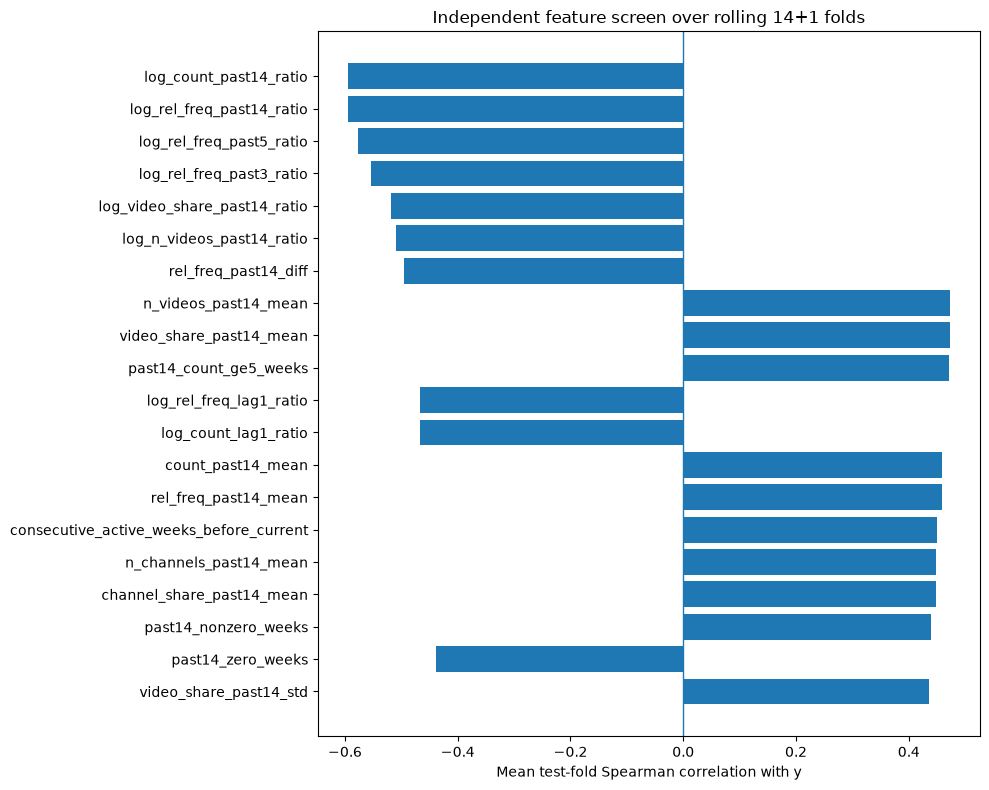

In [13]:
plot_df = feature_screen.head(20).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df["feature"], plot_df["mean_spearman_test"])
plt.axvline(0, linewidth=1)
plt.xlabel("Mean test-fold Spearman correlation with y")
plt.title("Independent feature screen over rolling 14+1 folds")
plt.tight_layout()
plt.show()


## 14. Model comparison


In [14]:
models = {
    "dummy_mean": DummyRegressor(strategy="mean"),

    "ridge": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        Ridge(alpha=1.0)
    ),

    "lasso": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        Lasso(alpha=0.0005, max_iter=5000, random_state=RANDOM_STATE)
    ),

    "decision_tree_depth_8": DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ),

    "random_forest_tiny": RandomForestRegressor(
        n_estimators=50,
        max_depth=9,
        min_samples_leaf=80,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "extra_trees_tiny": ExtraTreesRegressor(
        n_estimators=50,
        max_depth=9,
        min_samples_leaf=80,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

fold_prediction_parts = []
fold_results = []
importance_rows = []

for fold in tqdm(rolling_folds, desc="model folds"):
    fold_id = fold["fold_id"]
    train_weeks = fold["train_feature_weeks"]
    test_week = fold["test_feature_week"]

    train_df = model_df[model_df["time_id"].isin(train_weeks)].copy()
    test_df = model_df[model_df["time_id"] == test_week].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    X_train = train_df[feature_cols]
    y_train = train_df["y"]
    X_test = test_df[feature_cols]
    y_test = test_df["y"]

    pred_part = test_df[[
        "word", "time_id", "count", "next_count", "rel_freq", "next_rel_freq",
        "n_videos", "n_channels", "likes",
        "top_video_fraction", "video_entropy", "video_hhi",
        "top_channel_fraction", "channel_entropy", "channel_hhi",
        "weeks_since_last_seen", "consecutive_active_weeks_before_current",
        "consecutive_ge5_weeks_before_current", "is_reactivated_after_gap",
        "is_new_after_14_weeks_absent",
        "actual_growth_ratio_smoothed",
        "y", "is_positive_growth", "is_doubled", "is_halved"
    ]].copy()
    pred_part["fold_id"] = fold_id

    for name, model in models.items():
        # Optional count weights for tree models.
        sample_weight = None
        if USE_COUNT_WEIGHTS_FOR_TREE_MODELS and name in ["decision_tree_depth_8", "random_forest_tiny", "extra_trees_tiny"]:
            sample_weight = np.power(train_df["count"].clip(lower=1), COUNT_WEIGHT_POWER)
            sample_weight = np.minimum(sample_weight, COUNT_WEIGHT_CAP)

        if sample_weight is not None:
            fitted = model.fit(X_train, y_train, sample_weight=sample_weight)
        else:
            fitted = model.fit(X_train, y_train)

        pred = fitted.predict(X_test)

        pred_part[f"pred_{name}"] = pred

        fold_results.append({
            "fold_id": fold_id,
            "model": name,
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_week": test_week,
            "rmse": rmse(y_test, pred),
            "mae": mean_absolute_error(y_test, pred),
            "r2": r2_score(y_test, pred) if len(y_test) > 1 else np.nan,
            "spearman": safe_spearman(y_test, pred),
            "mean_y_at_top_1pct": mean_y_at_top_pct(y_test, pred, pct=0.01),
            "share_positive_at_top_1pct": share_at_top_pct(test_df["is_positive_growth"], pred, pct=0.01),
            "share_doubled_at_top_1pct": share_at_top_pct(test_df["is_doubled"], pred, pct=0.01),
        })

        if name in ["random_forest_tiny", "extra_trees_tiny"] and hasattr(fitted, "feature_importances_"):
            importances = fitted.feature_importances_
            for feat, val in zip(feature_cols, importances):
                importance_rows.append({
                    "fold_id": fold_id,
                    "model": name,
                    "feature": feat,
                    "importance": val,
                })

    fold_prediction_parts.append(pred_part)

predictions = pd.concat(fold_prediction_parts, ignore_index=True)
fold_results_df = pd.DataFrame(fold_results)
importance_df = pd.DataFrame(importance_rows)

# Pooled model results.
model_rows = []

for name in models.keys():
    pred_col = f"pred_{name}"
    y_true = predictions["y"]
    pred = predictions[pred_col]

    model_rows.append({
        "model": name,
        "pooled_rows": len(predictions),
        "rmse": rmse(y_true, pred),
        "mae": mean_absolute_error(y_true, pred),
        "r2": r2_score(y_true, pred),
        "spearman": safe_spearman(y_true, pred),
        "mean_y_at_top_1pct": mean_y_at_top_pct(y_true, pred, pct=0.01),
        "share_positive_at_top_1pct": share_at_top_pct(predictions["is_positive_growth"], pred, pct=0.01),
        "share_doubled_at_top_1pct": share_at_top_pct(predictions["is_doubled"], pred, pct=0.01),
    })

model_results = (
    pd.DataFrame(model_rows)
    .sort_values(["spearman", "mean_y_at_top_1pct"], ascending=False)
    .reset_index(drop=True)
)

if len(importance_df):
    importance_summary = (
        importance_df
        .groupby(["model", "feature"], as_index=False)
        .agg(
            mean_importance=("importance", "mean"),
            median_importance=("importance", "median"),
            std_importance=("importance", "std"),
            folds=("importance", "count"),
        )
        .sort_values(["model", "mean_importance"], ascending=[True, False])
        .reset_index(drop=True)
    )
else:
    importance_summary = pd.DataFrame()

predictions.to_csv(OUT_DIR / "test_predictions.csv", index=False)
fold_results_df.to_csv(OUT_DIR / "rolling_fold_results.csv", index=False)
model_results.to_csv(OUT_DIR / "model_results.csv", index=False)
importance_df.to_csv(OUT_DIR / "tree_fold_importance.csv", index=False)
importance_summary.to_csv(OUT_DIR / "tree_importance_summary.csv", index=False)

print("Pooled model results:")
display(model_results)

print("Fold result summary:")
display(fold_results_df.select_dtypes(include=[np.number]).describe())

if len(importance_summary):
    print("Top tree importances:")
    display(importance_summary.groupby("model").head(20))


model folds: 100%|██████████| 45/45 [08:22<00:00, 11.18s/it]


Pooled model results:


,model,pooled_rows,rmse,mae,r2,spearman,mean_y_at_top_1pct,share_positive_at_top_1pct,share_doubled_at_top_1pct
0,random_forest_tiny,170867,0.604800,0.429878,0.432300,0.616730,0.588703,0.898126,0.417447
1,lasso,170867,0.611145,0.435609,0.420325,0.604226,0.593090,0.888759,0.423302
2,ridge,170867,0.611088,0.436523,0.420434,0.603888,0.567504,0.873536,0.413349
3,decision_tree_depth_8,170867,0.619717,0.439963,0.403950,0.598681,0.522746,0.857728,0.375293
4,extra_trees_tiny,170867,0.618891,0.444043,0.405538,0.591612,0.565272,0.889344,0.394614
5,dummy_mean,170867,0.802616,0.590296,0.000203,0.014704,-0.380561,0.338407,0.033372


Fold result summary:


,fold_id,train_rows,test_rows,test_week,rmse,mae,r2,spearman,mean_y_at_top_1pct,share_positive_at_top_1pct,share_doubled_at_top_1pct
count,270.00000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,225.000000,270.000000,270.000000,270.000000
mean,23.00000,47849.355556,3797.044444,36.00000,0.645401,0.463628,0.347007,0.609972,0.426647,0.799753,0.344683
std,13.01129,8687.236165,712.988567,13.01129,0.075915,0.061710,0.159560,0.028227,0.340422,0.200891,0.158354
min,1.00000,33067.000000,2300.000000,14.00000,0.542071,0.388619,-0.003952,0.546720,-0.823607,0.210526,0.000000
25%,12.00000,39968.000000,3401.000000,25.00000,0.600053,0.425239,0.369990,0.588379,0.423164,0.793357,0.276045
50%,23.00000,50344.000000,3875.000000,36.00000,0.618310,0.440885,0.408592,0.609165,0.553772,0.868993,0.390244
75%,34.00000,52868.000000,4410.000000,47.00000,0.645596,0.463991,0.439016,0.626931,0.624245,0.926603,0.450000
max,45.00000,62173.000000,5839.000000,58.00000,0.861714,0.643705,0.508451,0.680798,0.836930,1.000000,0.638889


Top tree importances:


,model,feature,mean_importance,median_importance,std_importance,folds
0,extra_trees_tiny,video_entropy_past14_mean,0.119863,0.122035,0.013475,45
1,extra_trees_tiny,past14_count_ge5_weeks,0.086416,0.089687,0.015907,45
2,extra_trees_tiny,log_count_past14_ratio,0.068361,0.068440,0.007907,45
3,extra_trees_tiny,past14_zero_weeks,0.067885,0.079655,0.030553,45
4,extra_trees_tiny,past14_nonzero_weeks,0.053157,0.060513,0.021905,45
5,extra_trees_tiny,top_video_fraction,0.045544,0.044148,0.009625,45
6,extra_trees_tiny,log_rel_freq_past5_ratio,0.036764,0.035972,0.005835,45
7,extra_trees_tiny,consecutive_active_weeks_before_current,0.036489,0.039306,0.013649,45
8,extra_trees_tiny,log_rel_freq_past14_ratio,0.035636,0.035567,0.007414,45
9,extra_trees_tiny,video_hhi,0.031478,0.028647,0.009779,45


## 15. Model comparison plot


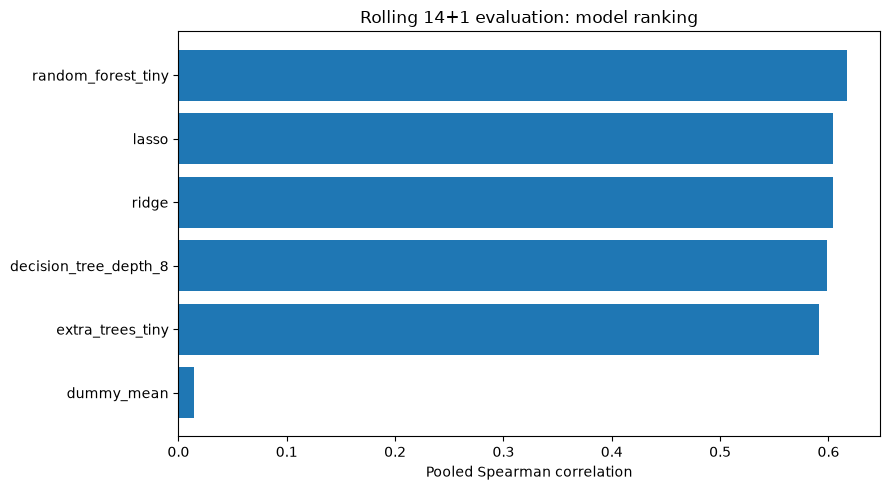

In [15]:
plot_results = model_results.sort_values("spearman", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_results["model"], plot_results["spearman"])
plt.xlabel("Pooled Spearman correlation")
plt.title("Rolling 14+1 evaluation: model ranking")
plt.tight_layout()
plt.show()


## 16. Top predictions and largest actual moves


In [16]:
best_model_name = model_results.iloc[0]["model"]
pred_col = f"pred_{best_model_name}"

print("Best model by pooled Spearman:", best_model_name)

# Filter top-prediction tables for readability only.
predictions_for_top_tables = predictions[predictions["count"] >= MIN_COUNT_FOR_TOP_TABLES].copy()
if len(predictions_for_top_tables) == 0:
    predictions_for_top_tables = predictions.copy()

# Keep unfiltered versions for checks.
top_predictions_rows_unfiltered = predictions.sort_values(pred_col, ascending=False).head(100)
top_predictions_rows = predictions_for_top_tables.sort_values(pred_col, ascending=False).head(100)

top_predictions_unique_words = (
    predictions_for_top_tables
    .sort_values(pred_col, ascending=False)
    .drop_duplicates("word")
    .head(100)
)

top_actual_growth_words = (
    predictions
    .sort_values("y", ascending=False)
    .drop_duplicates("word")
    .head(100)
)

bottom_actual_decay_words = (
    predictions
    .sort_values("y", ascending=True)
    .drop_duplicates("word")
    .head(100)
)

top_predictions_rows_unfiltered.to_csv(OUT_DIR / "top_predictions_rows_unfiltered.csv", index=False)
top_predictions_rows.to_csv(OUT_DIR / "top_predictions_rows.csv", index=False)
top_predictions_unique_words.to_csv(OUT_DIR / "top_predictions_unique_words.csv", index=False)
top_actual_growth_words.to_csv(OUT_DIR / "top_actual_growth_words.csv", index=False)
bottom_actual_decay_words.to_csv(OUT_DIR / "bottom_actual_decay_words.csv", index=False)

# Count distribution in the top predictions.
def count_bucket(x):
    if x < 10:
        return "5-9"
    if x < 20:
        return "10-19"
    if x < 50:
        return "20-49"
    if x < 100:
        return "50-99"
    return "100+"

count_diag_parts = []
for label, frame in [
    ("all_test_rows", predictions),
    ("top100_unfiltered", top_predictions_rows_unfiltered),
    ("top100_filtered", top_predictions_rows),
    ("top1pct_unfiltered", predictions.sort_values(pred_col, ascending=False).head(max(1, int(len(predictions) * 0.01)))),
]:
    tmp = frame.copy()
    tmp["count_bucket"] = tmp["count"].apply(count_bucket)
    dist = tmp["count_bucket"].value_counts(normalize=True).rename("share").reset_index()
    dist.columns = ["count_bucket", "share"]
    dist["group"] = label
    dist["rows"] = len(tmp)
    count_diag_parts.append(dist)

count_bucket_diagnostics = pd.concat(count_diag_parts, ignore_index=True)
count_bucket_diagnostics.to_csv(OUT_DIR / "top_prediction_count_bucket_diagnostics.csv", index=False)

# Actual top-growth rows missed by the model.
actual_top_1pct = predictions.nlargest(max(1, int(len(predictions) * 0.01)), "y").copy()
pred_top_1pct = predictions.nlargest(max(1, int(len(predictions) * 0.01)), pred_col).copy()
actual_top_keys = set(zip(actual_top_1pct["word"], actual_top_1pct["time_id"]))
pred_top_keys = set(zip(pred_top_1pct["word"], pred_top_1pct["time_id"]))
missed_top_actual = actual_top_1pct[
    ~actual_top_1pct.set_index(["word", "time_id"]).index.isin(pred_top_keys)
].copy()
missed_top_actual.to_csv(OUT_DIR / "missed_top_actual_growth_rows.csv", index=False)

overlap_summary = pd.DataFrame([{
    "actual_top_1pct_rows": len(actual_top_1pct),
    "pred_top_1pct_rows": len(pred_top_1pct),
    "overlap_rows": len(actual_top_keys & pred_top_keys),
    "overlap_share_of_actual_top_1pct": len(actual_top_keys & pred_top_keys) / max(1, len(actual_top_keys)),
    "top_table_min_count": MIN_COUNT_FOR_TOP_TABLES,
}])
overlap_summary.to_csv(OUT_DIR / "top1pct_overlap_summary.csv", index=False)

show_cols = [
    "word", "fold_id", "time_id",
    "count", "next_count", "rel_freq", "next_rel_freq",
    "n_videos", "n_channels",
    "top_video_fraction", "video_entropy", "top_channel_fraction", "channel_entropy",
    "weeks_since_last_seen", "consecutive_active_weeks_before_current", "is_reactivated_after_gap",
    "actual_growth_ratio_smoothed", "y", pred_col,
    "is_positive_growth", "is_doubled", "is_halved",
]

print("Top model predictions, unique words, filtered to count >=", MIN_COUNT_FOR_TOP_TABLES)
display(top_predictions_unique_words[show_cols].head(20))

print("Count-bucket diagnostics:")
display(count_bucket_diagnostics)

print("Top 1% overlap summary:")
display(overlap_summary)

print("Top actual growth rows, unique words:")
display(top_actual_growth_words[show_cols].head(20))

print("Bottom actual decay rows, unique words:")
display(bottom_actual_decay_words[show_cols].head(20))


Best model by pooled Spearman: random_forest_tiny
Top model predictions, unique words, filtered to count >= 10


,word,fold_id,time_id,count,next_count,rel_freq,next_rel_freq,n_videos,n_channels,top_video_fraction,video_entropy,top_channel_fraction,channel_entropy,weeks_since_last_seen,consecutive_active_weeks_before_current,is_reactivated_after_gap,actual_growth_ratio_smoothed,y,pred_random_forest_tiny,is_positive_growth,is_doubled,is_halved
162421,id,44,57,11.0,31.0,0.000068,0.000136,10.0,8.0,0.181818,0.986660,0.272727,0.948450,1.0,57.0,0,1.957265,0.671548,0.586339,1,0,0
169786,social,45,58,10.0,21.0,0.000044,0.000111,8.0,4.0,0.200000,0.973976,0.500000,0.842738,1.0,58.0,0,2.466359,0.902743,0.571977,1,1,0
59647,american,19,32,11.0,19.0,0.000105,0.000171,9.0,3.0,0.181818,0.976615,0.636364,0.782776,1.0,32.0,0,1.606729,0.474201,0.556156,1,0,0
158630,option,43,56,10.0,24.0,0.000069,0.000147,10.0,6.0,0.100000,1.000000,0.400000,0.898244,1.0,56.0,0,2.088722,0.736552,0.545757,1,1,0
61997,respect,19,32,11.0,18.0,0.000105,0.000162,9.0,5.0,0.272727,0.954966,0.545455,0.804346,1.0,32.0,0,1.524333,0.421557,0.544151,1,0,0
53048,deal,17,30,12.0,25.0,0.000098,0.000236,10.0,4.0,0.166667,0.978838,0.416667,0.892080,1.0,30.0,0,2.355712,0.856843,0.542492,1,1,0
35764,showing,12,25,11.0,25.0,0.000096,0.000218,10.0,8.0,0.181818,0.986660,0.363636,0.910720,1.0,25.0,0,2.216288,0.795834,0.541919,1,1,0
170368,truth,45,58,10.0,40.0,0.000044,0.000211,8.0,5.0,0.300000,0.948813,0.400000,0.881353,1.0,58.0,0,4.645933,1.535992,0.541394,1,1,0
30615,hi,11,24,13.0,41.0,0.000108,0.000358,13.0,9.0,0.076923,1.000000,0.230769,0.954908,1.0,24.0,0,3.242626,1.176384,0.536844,1,1,0
63288,battle,20,33,10.0,23.0,0.000090,0.000225,10.0,6.0,0.100000,1.000000,0.300000,0.946412,1.0,33.0,0,2.422858,0.884948,0.526619,1,1,0


Count-bucket diagnostics:


,count_bucket,share,group,rows
0,5-9,0.451843,all_test_rows,170867
1,10-19,0.262818,all_test_rows,170867
2,20-49,0.175563,all_test_rows,170867
3,50-99,0.062552,all_test_rows,170867
4,100+,0.047224,all_test_rows,170867
5,5-9,0.990000,top100_unfiltered,100
6,10-19,0.010000,top100_unfiltered,100
7,10-19,0.960000,top100_filtered,100
8,20-49,0.040000,top100_filtered,100
9,5-9,0.851288,top1pct_unfiltered,1708


Top 1% overlap summary:


,actual_top_1pct_rows,pred_top_1pct_rows,overlap_rows,overlap_share_of_actual_top_1pct,top_table_min_count
0,1708,1708,191,0.111827,10


Top actual growth rows, unique words:


,word,fold_id,time_id,count,next_count,rel_freq,next_rel_freq,n_videos,n_channels,top_video_fraction,video_entropy,top_channel_fraction,channel_entropy,weeks_since_last_seen,consecutive_active_weeks_before_current,is_reactivated_after_gap,actual_growth_ratio_smoothed,y,pred_random_forest_tiny,is_positive_growth,is_doubled,is_halved
134402,d1,38,51,5.0,280.0,0.000035,0.001869,3.0,1.0,0.600000,0.864974,1.000000,0.000000,1.0,5.0,0,48.658049,3.884817,-0.644967,1,1,0
28103,shock,10,23,5.0,203.0,0.000041,0.001681,5.0,3.0,0.200000,1.000000,0.400000,0.960230,1.0,1.0,0,37.548280,3.625628,-0.431664,1,1,0
139035,drm,39,52,6.0,233.0,0.000040,0.001479,3.0,2.0,0.500000,0.920620,0.833333,0.650022,6.0,0.0,1,34.166209,3.531237,-1.608049,1,1,0
170799,xenoblade,45,58,5.0,104.0,0.000022,0.000550,2.0,1.0,0.800000,0.721928,1.000000,0.000000,1.0,2.0,0,22.885521,3.130504,-1.478469,1,1,0
45576,files,15,28,5.0,108.0,0.000037,0.000886,5.0,4.0,0.200000,1.000000,0.400000,0.960964,1.0,19.0,0,21.710245,3.077784,0.424966,1,1,0
121929,fools,35,48,8.0,170.0,0.000050,0.001148,6.0,4.0,0.250000,0.967132,0.500000,0.875000,1.0,9.0,0,21.622977,3.073756,-0.616973,1,1,0
31942,security,11,24,8.0,159.0,0.000066,0.001388,8.0,5.0,0.125000,1.000000,0.375000,0.928383,1.0,24.0,0,19.793580,2.985358,0.423919,1,1,0
31517,pokemon,11,24,10.0,195.0,0.000083,0.001703,9.0,3.0,0.200000,0.984859,0.700000,0.729847,1.0,13.0,0,19.639935,2.977565,0.079807,1,1,0
54391,mod,17,30,8.0,139.0,0.000065,0.001310,7.0,6.0,0.250000,0.979570,0.250000,0.967132,1.0,30.0,0,18.951664,2.941892,0.144531,1,1,0
54927,reddit,17,30,10.0,167.0,0.000082,0.001574,4.0,1.0,0.700000,0.678390,1.000000,0.000000,1.0,12.0,0,18.421186,2.913501,-0.263827,1,1,0


Bottom actual decay rows, unique words:


,word,fold_id,time_id,count,next_count,rel_freq,next_rel_freq,n_videos,n_channels,top_video_fraction,video_entropy,top_channel_fraction,channel_entropy,weeks_since_last_seen,consecutive_active_weeks_before_current,is_reactivated_after_gap,actual_growth_ratio_smoothed,y,pred_random_forest_tiny,is_positive_growth,is_doubled,is_halved
20895,kardvin,8,21,113.0,0.0,0.001488,0.000000,10.0,2.0,0.141593,0.963456,0.911504,0.431428,999.0,0.0,0,0.004291,-5.451215,-1.614227,0,0,1
17977,kwarden,7,20,122.0,0.0,0.001213,0.000000,18.0,2.0,0.098361,0.951510,0.868852,0.560577,1.0,1.0,0,0.005407,-5.220050,-1.426062,0,0,1
22423,aloo,9,22,56.0,0.0,0.000718,0.000000,12.0,3.0,0.482143,0.731796,0.821429,0.526394,1.0,1.0,0,0.005628,-5.179992,-1.614638,0,0,1
83470,benin,26,39,85.0,0.0,0.000673,0.000000,3.0,1.0,0.964706,0.159432,1.000000,0.000000,17.0,0.0,1,0.005911,-5.130950,-2.415557,0,0,1
88651,highguard,27,40,77.0,0.0,0.000616,0.000000,9.0,2.0,0.272727,0.790812,0.922078,0.394815,1.0,1.0,0,0.006072,-5.104095,-1.403763,0,0,1
143596,drm,40,53,233.0,1.0,0.001479,0.000007,28.0,1.0,0.193133,0.872893,1.000000,0.000000,1.0,1.0,0,0.006955,-4.968360,-1.387549,0,0,1
106015,scout,31,44,50.0,0.0,0.000385,0.000000,1.0,1.0,1.000000,0.000000,1.000000,0.000000,5.0,0.0,1,0.008532,-4.763929,-2.363608,0,0,1
60747,frieren,19,32,54.0,0.0,0.000514,0.000000,1.0,1.0,1.000000,0.000000,1.000000,0.000000,1.0,1.0,0,0.008693,-4.745215,-2.595947,0,0,1
106017,scouts,31,44,43.0,0.0,0.000331,0.000000,1.0,1.0,1.000000,0.000000,1.000000,0.000000,2.0,0.0,1,0.009905,-4.614717,-2.383833,0,0,1
9581,sakurai,4,17,38.0,0.0,0.000494,0.000000,1.0,1.0,1.000000,0.000000,1.000000,0.000000,12.0,0.0,1,0.010037,-4.601447,-2.619707,0,0,1


## 17. Save outputs


In [17]:
summary = pd.DataFrame([{
    "raw_dir": str(RAW_DIR.resolve()),
    "out_dir": str(OUT_DIR.resolve()),
    "json_files_used": len(json_files),
    "use_latest_batch_per_channel": USE_LATEST_BATCH_PER_CHANNEL,
    "raw_comment_rows_loaded": len(df),
    "comments_in_retained_window": len(window_df),
    "skip_recent_weeks": SKIP_RECENT_WEEKS,
    "retained_weeks": N_WEEKS,
    "min_week_back": MIN_WEEK_BACK,
    "max_week_back_inclusive": MAX_WEEK_BACK_INCLUSIVE,
    "rolling_train_window": ROLLING_TRAIN_WINDOW,
    "rolling_folds": len(rolling_folds),
    "min_current_count": MIN_CURRENT_COUNT,
    "min_count_for_top_tables": MIN_COUNT_FOR_TOP_TABLES,
    "remove_stopwords": REMOVE_STOPWORDS,
    "use_count_weights_for_tree_models": USE_COUNT_WEIGHTS_FOR_TREE_MODELS,
    "target_alpha": TARGET_ALPHA,
    "target_definition": "y = log(((next_count + alpha) / next_token_count) / ((count + alpha) / token_count))",
    "feature_definition": "baseline ratios, source spread, reactivation, persistence, slopes, volatility, engagement, and word controls",
    "model_rows": len(model_df),
    "unique_model_words": model_df["word"].nunique(),
    "pooled_test_rows": len(predictions),
    "pooled_test_mean_y": predictions["y"].mean(),
    "pooled_test_share_positive": predictions["is_positive_growth"].mean(),
    "pooled_test_share_doubled": predictions["is_doubled"].mean(),
    "pooled_test_share_halved": predictions["is_halved"].mean(),
    "best_model_by_pooled_spearman": best_model_name,
}])

summary.to_csv(OUT_DIR / "eda_model_run_summary.csv", index=False)

compact_cols = [
    "word", "time_id", "count", "next_count", "rel_freq", "next_rel_freq",
    "n_videos", "n_channels", "likes",
    "top_video_fraction", "video_entropy", "video_hhi",
    "top_channel_fraction", "channel_entropy", "channel_hhi",
    "weeks_since_last_seen", "consecutive_active_weeks_before_current",
    "consecutive_ge5_weeks_before_current", "is_reactivated_after_gap",
    "is_new_after_14_weeks_absent",
    "actual_growth_ratio_smoothed",
    "y", "is_positive_growth", "is_doubled", "is_halved"
]
model_df[compact_cols].to_csv(OUT_DIR / "model_rows_compact.csv", index=False)

print("Saved outputs to:", OUT_DIR.resolve())
display(summary)

print("Output files:")
for p in sorted(OUT_DIR.glob("*")):
    print(" ", p.name)


Saved outputs to: /Users/yasir/data-science/EarlySlangDetection/src/data/signed_log_growth_richer_features_outputs


,raw_dir,out_dir,json_files_used,use_latest_batch_per_channel,raw_comment_rows_loaded,comments_in_retained_window,skip_recent_weeks,retained_weeks,min_week_back,max_week_back_inclusive,rolling_train_window,rolling_folds,min_current_count,min_count_for_top_tables,remove_stopwords,use_count_weights_for_tree_models,target_alpha,target_definition,feature_definition,model_rows,unique_model_words,pooled_test_rows,pooled_test_mean_y,pooled_test_share_positive,pooled_test_share_doubled,pooled_test_share_halved,best_model_by_pooled_spearman
0,/Users/yasir/data-science/EarlySlangDetection/raw,/Users/yasir/data-science/EarlySlangDetection/...,75,False,1739303,824685,2,60,2,61,14,45,5,10,True,True,0.5,y = log(((next_count + alpha) / next_token_cou...,"baseline ratios, source spread, reactivation, ...",203934,15717,170867,-0.352513,0.355692,0.042612,0.244342,random_forest_tiny


Output files:
  bottom_actual_decay_words.csv
  comment_window_summary_rows.csv
  eda_model_run_summary.csv
  feature_cols.txt
  feature_screen_summary.csv
  foldwise_feature_screen.csv
  missed_top_actual_growth_rows.csv
  model_results.csv
  model_rows_compact.csv
  rolling_fold_results.csv
  rolling_folds.csv
  test_predictions.csv
  top1pct_overlap_summary.csv
  top_actual_growth_words.csv
  top_prediction_count_bucket_diagnostics.csv
  top_predictions_rows.csv
  top_predictions_rows_unfiltered.csv
  top_predictions_unique_words.csv
  tree_fold_importance.csv
  tree_importance_summary.csv
  week_summary.csv
